In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

### Read Decision Forests Results

In [4]:
Ts_DF = [2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)

PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_optimal_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_opt_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 13)
(10, 13)


### Read Neural Net Results

In [17]:
Ts_NN = [128,256,512]+[750]+[1024,1250,1500,2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/NN/onehot/NN_onehot_w_lookahead_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_NN):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_NN_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_NN_arr.shape)

PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/NN/oracle/NN_oracle_w_lookahead_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_NN):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_NN_opt_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_NN_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 8)
(10, 8)


In [18]:
PREGRETS_PAFM_NN_arr

array([[1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.06555431, 0.95004579, 1.05524927, 0.048681  , 0.00466332,
        0.01863   , 0.0118098 , 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.00466546, 0.        ],
       [1.02055431, 0.99581982, 0.7427414 , 0.05344634, 0.02643613,
        0.0118098 , 0.004665

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_57356/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


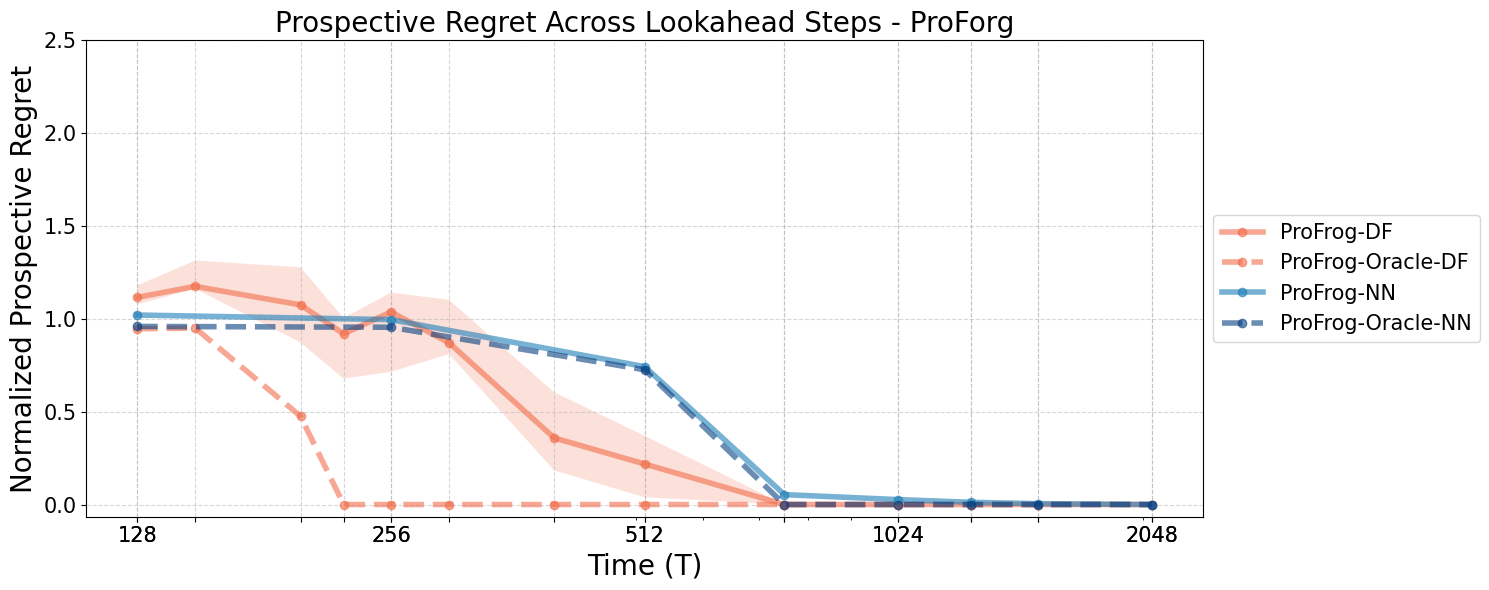

In [19]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 20

pafm_df, pafm_df_opt = get_close_colors("OrRd", start = 0.6, delta = 0.3, n = 2) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
colors = {"PAFM_oh_RF": pafm_df,
          "PAFM_opt_RF":pafm_df,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn_opt}

## Plot DF
median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
plt.plot(Ts_DF, median,color=colors["PAFM_oh_RF"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProFrog-DF')
plt.fill_between(Ts_DF, q25, q75, color=colors["PAFM_oh_RF"], alpha=0.20, edgecolor="none")


median = np.min(PREGRETS_PAFM_DF_opt_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_DF_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_DF_opt_arr, 75, axis=0)
plt.plot(Ts_DF, median,color=colors["PAFM_opt_RF"], lw = linewidth,alpha = 0.6,label = 'ProFrog-Oracle-DF',marker='o',linestyle = '--')
# plt.fill_between(Ts, q25, q75, color=colors["PAFM_opt_RF"], alpha=0.25, edgecolor="none")

## Plot NN
median = np.median(PREGRETS_PAFM_NN_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 75, axis=0)
plt.plot(Ts_NN, median,color=colors["PAFM_oh_NN"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProFrog-NN')
plt.fill_between(Ts_NN, q25, q75, color=colors["PAFM_oh_NN"], alpha=0.20, edgecolor="none")


median = np.min(PREGRETS_PAFM_NN_opt_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_NN_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_NN_opt_arr, 75, axis=0)
plt.plot(Ts_NN, median,color=colors["PAFM_opt_NN"], lw = linewidth,alpha = 0.6,label = 'ProFrog-Oracle-NN',marker='o',linestyle = '--')
# plt.fill_between(Ts, q25, q75, color=colors["PAFM_oh_NN"], alpha=0.25, edgecolor="none")


plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
plt.xscale('log')

xticks = Ts_DF + Ts_NN
xticklabels = [str(v) if v in [128,256,512,1024,2048] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)

# plt.xticks(Ts_PAFM+Ts_PVFM, labels=[str(v) for v in Ts_PAFM+Ts_PVFM])
plt.yticks([0,0.5,1,1.5,2,2.5],fontsize = fontsize-5)
plt.title('Prospective Regret Across Lookahead Steps - ProForg',fontsize = fontsize)
# plt.xlim(0,700000)                  
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5),fontsize = fontsize-5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()